# Machine Learning Technologies Image Project 2026

* **Name:** Tomás Pettit
* **Student ID:** G00419414

## Introduction
Working with the Garbage Classification dataset in Google Colab requires careful setup to ensure efficient model training and experimentation.

Before running any code cells, it is essential to change the runtime type to **T4 GPU**. Training image‑based machine learning models on a CPU is extremely slow and can significantly delay progress, whereas the T4 GPU provides the necessary acceleration to handle large datasets and deep learning architectures more effectively.

Using GPU hardware not only speeds up training but also improves the overall workflow, making the development process smoother and more responsive.

## Workflow

1.  Data Loading & Understanding
2.  Data Preprocessing
3.  Train / Validation / Test Split
4.  Model Training
5.  Hyperparameter Tuning (Cross-Validation)
6.  Model Comparison
7.  Final Model Selection
8.  Test Set Evaluation
9.  Conclusion

## 1. Imports
This section initialises the environment, imports required libraries, and sets a fixed random seed to ensure reproducibility.

In [1]:
# NumPy and Pandas
import numpy as np
import pandas as pd

# Image processings
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Misc
import time
import os
from datetime import datetime
from pathlib import Path

# Preprocessing function for MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# TensorFlow (for deep learning models)
import tensorflow as tf
from tensorflow.keras import models, layers

I0000 00:00:1776598843.449364   13289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776598843.450391   13289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776598844.842508   13289 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776598847.272332   13289 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
RANDOM_SEED = 419414 # My Student ID (No 'G00')
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# Set up parameters for loading the dataset
# Image Size
IMAGE_SIZE = [(64, 64), (128, 128), (224, 224)]

# Batch Size
BATCH_SIZE = 32

# Epoch
EPOCH = [3, 10, 15]

## 2. Data Loading and Understanding - Garbage Dataset

The dataset consists of images of different types of waste materials. Each class is stored in a separate folder.

I will:

-   Load images
-   Convert to feature vectors
-   Create labels
-   Inspect dataset structure

And check to be sure if the garbage data has been succeeded using `import os`.

In [4]:
DATA_DIR = Path("data/garbage")

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())

Dataset exists: True
Dataset path: /workspaces/ML-Assignment/data/garbage


In [5]:
# Load the dataset using Keras utility
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],  # Using the second image size (128, 128) for loading
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.


E0000 00:00:1776598849.723407   13289 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Class Distribution of Garbage Datasets
The dataset exhibits a moderate class imbalance, with the number of samples varying across categories.

For example, the 'clothes' class contains 1892 images, whereas the 'trash' class contains only 453 images. This represents a difference of approximately four times between the largest and smallest classes.

Such imbalance may affect model performance, as models can become biased towards classes with more training samples. This will be considered during evaluation using class-wise metrics such as confusion matrices and classification reports.

In [6]:
# Class distribution
class_names = [d.name for d in DATA_DIR.iterdir() if d.is_dir()]
class_counts = {}

for class_name in class_names:
    class_path = DATA_DIR / class_name
    image_files = [f for f in class_path.iterdir() if f.is_file()]
    class_counts[class_name] = len(image_files)

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df

,Class,Count
0,battery,756
1,glass,1736
2,trash,453
3,metal,930
4,clothes,1892
5,biological,699
6,paper,1336
7,plastic,1597
8,cardboard,1411
9,shoes,1449


### Figure 1: Bar Chart Garbage Distribution

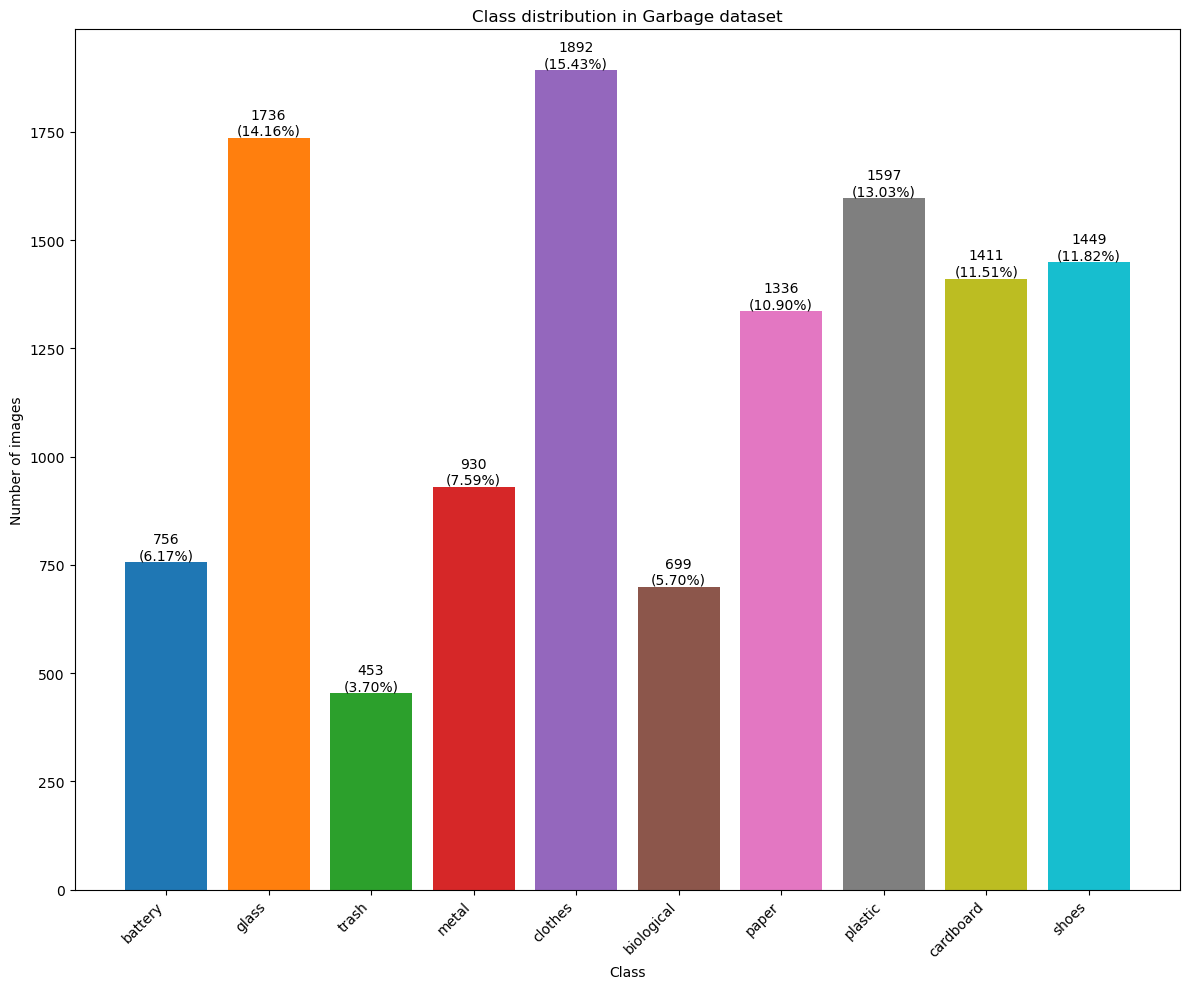

In [7]:
# Color variables (10 bars)
COLOR_BARS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]

# Percentage of images out of total images
total_images = sum(class_counts.values())
percentages = {class_name: (count / total_images) * 100 for class_name, count in class_counts.items()}

# Visualize class distribution
plt.figure(figsize=(12, 10))
plt.bar(class_counts.keys(), class_counts.values(), color=COLOR_BARS)

for i, count in enumerate(class_counts.values()):
    plt.text(i, count, f"{count}\n({percentages[class_names[i]]:.2f}%)", ha='center', va='bottom')

plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in Garbage dataset")
plt.tight_layout()
plt.show()

### Figure 2: Sample Images from the dataset & Pixel Values

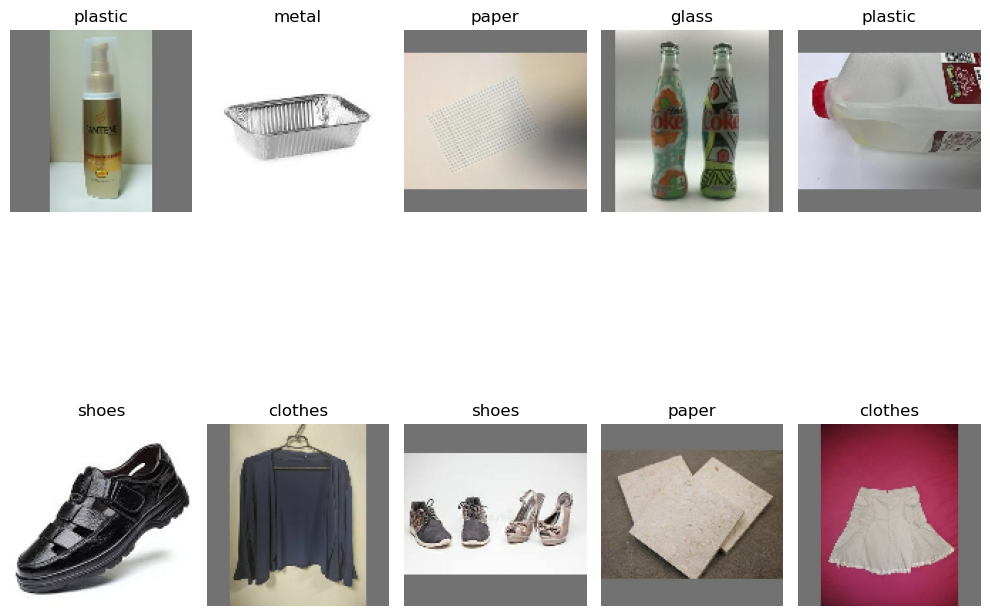

In [8]:
# Sample some images from the dataset
images_batch, labels_batch = next(iter(full_ds))

plt.figure(figsize=(10, 10))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    plt.title(full_ds.class_names[labels_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Check pixel value range and dtype

In [9]:
print("Pixel dtype:", images_batch.dtype)
print("Min pixel value:", tf.reduce_min(images_batch).numpy())
print("Max pixel value:", tf.reduce_max(images_batch).numpy())

Pixel dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 255.0


### Check for Corrupted Images

In [10]:
bad_files = []

for class_name in class_names:
    class_path = DATA_DIR / class_name
    for file_path in class_path.iterdir():
        try:
            with Image.open(file_path) as img:
                img.verify()  # check if image is valid
        except Exception:
            bad_files.append(file_path)

print("Number of corrupted images:", len(bad_files))

Number of corrupted images: 0


## 3. Train (70%), Validation (10%), and Test Split (20%)

In this section, the dataset is divided into training, validation, and test sets.

-   The training set is used to train the models
-   The validation set is used for model tuning and selection
-   The test set is reserved for final evaluation only

A fixed random seed is used to ensure reproducibility of the split.

> A validation set of 10% was selected as it provides a sufficient amount of data for reliable model evaluation while preserving the majority of the dataset for training. Using a larger validation set would reduce the amount of data available for training, while a smaller validation set could lead to unreliable performance estimates.

In [11]:
# First Split: Train (70%) and Temporary (30%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],  # Using the second image size (128, 128) for loading
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],  # Using the second image size (128, 128) for loading],
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [12]:
# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()  # number of batches
val_size = temp_size // 3  # exactly 1/3 of temp

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [13]:
# Check sizes
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)

print("-------------------------------")
print("Approx total samples:")
print("Train:", train_batches * BATCH_SIZE)
print("Validation:", val_batches * BATCH_SIZE)
print("Test:", test_batches * BATCH_SIZE)

Train batches: 269
Validation batches: 38
Test batches: 77
-------------------------------
Approx total samples:
Train: 8608
Validation: 1216
Test: 2464


## 4. Preprocessing and Experimental Setup

In this section, the dataset is prepared for model training.

This includes:

-   Normalising pixel values
-   Defining the input image size
-   Preparing for later experiments (RGB vs greyscale, image size comparison, and overfitting control)

The preprocessing pipeline is designed to be consistent across experiments to ensure fair comparison between models.

In [14]:
# Normalisation layer to scale pixel values to [0, 1]
normalisation_layer = layers.Rescaling(1./255)

In [15]:
# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))